In [15]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)


(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


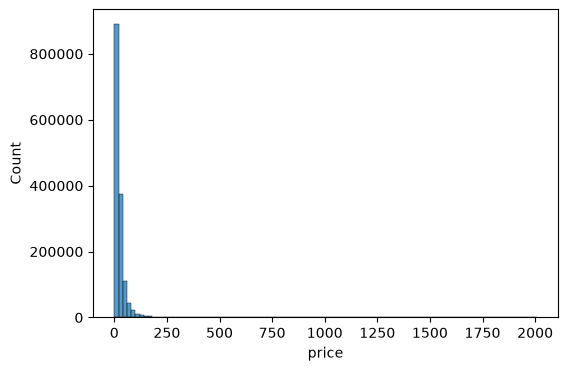

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [16]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

#원본 보관(백업용) 및 답 임시생성(그래프 생성용)
mercari_ori= mercari_df
y_labels = mercari_df['price']

plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()




mercari_df.value_counts('price').sort_index()

# y_labels 0처리 이후 다시 재조정예정


In [17]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# 가격이 2000이상인 데이터 제거
mercari_df = mercari_df[mercari_df['price']<2000]
print(f'2000이상 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

# 추가: 브랜드 and의 전처리(불용어 and와 겹치지 않게끔 전처리 진행)
mercari_df['brand_name'] = (
    mercari_df['brand_name']
    .str.replace(r'\bAND\b', 'brand_and', regex=True)
)

mercari_df['brand_name'].str.contains(
    r'\bbrand_and\b',
    na=False
).sum()

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)
2000이상 제거 후 : (1481652, 8)
train_id 제거 후 : (1481603, 7)


np.int64(1933)

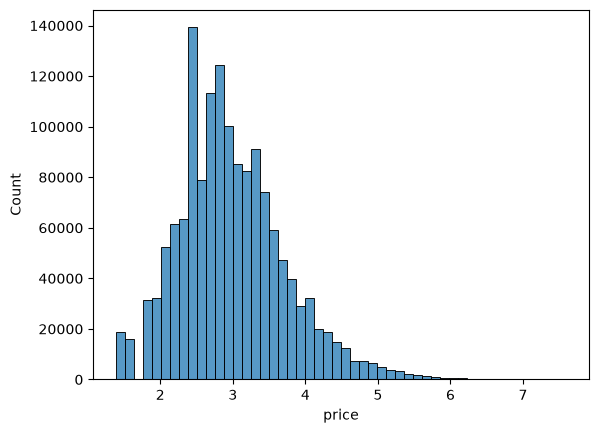

In [18]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [19]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

#텍스트 클리닝(소문자/공백)
def text_cleaning(text):
    
    # 소문자로 변환
    text = text.lower()
    
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words


In [20]:
mercari_df['item_description'].apply(type).value_counts()

item_description
<class 'str'>      1481597
<class 'float'>          6
Name: count, dtype: int64

In [21]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수

def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens


def preprocess_description(text):
    # 1. 결측치 처리 + 문자열 변환
    if pd.isna(text):
        text = 'No description yet'
    

    # 2. 클렌징 + 토큰화 + 불용어 제거
    tokens = preprocess_text(text)

    # 3. 리스트 → 문자열
    text = ' '.join(tokens)

    return text




In [22]:
mercari_df['item_description'] = (
    mercari_df['item_description']
    .apply(preprocess_description)
)
# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
3    new tags leather horses retail stand foot high...
4                    complete certificate authenticity
Name: item_description, dtype: str

In [23]:
#프로덕트 텍스트 새로 생성(name,brand_name, category_name) 함수 제작
def make_product_text(df):
    df['product_text'] = (
        df['name'].fillna('') + ' ' +
        df['brand_name'].fillna('') + ' ' +
        df['category_name'].fillna('').str.replace('/', ' ', regex=False)
    )

    df['product_text'] = (
        df['product_text']
        .apply(preprocess_text)
        .apply(lambda x: ' '.join(x))
    )

    return df

def fix_item_description(df):
    df[['item_description']=='no description yet'] = ' '
    df['item_description'] = (
    df['name'].fillna('') + ' ' +
    df['item_description'].fillna('')
    )
    
    return df

In [24]:
make_product_text(mercari_df)
fix_item_description(mercari_df)
mercari_df['product_text']

0          mlb cincinnati reds shirt size xl men tops shirts
1          razer blackwidow chroma keyboard razer electro...
2            ava viv blouse target women tops blouses blouse
3          leather horse statues home home cor home cor a...
4               24k gold plated rose women jewelry necklaces
                                 ...                        
1481598    free people inspired dress free people women d...
1481599    little mermaid handmade dress disney kids girl...
1481600    21 day fix containers eating plan sports outdo...
1481601    world markets lanterns home home cor home cor ...
1481602    brand new lux de ville wallet women women acce...
Name: product_text, Length: 1481603, dtype: str

In [25]:
#item_description에 이름 넣기
mercari_df[['item_description']=='not description yet'] = ' '
mercari_df['item_description'] = (
    mercari_df['name'].fillna('') + ' ' +
    mercari_df['item_description'].fillna('')
)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = (
    train_test_split(
        mercari_df[['product_text','item_description','item_condition_id','shipping']],
        y_labels,
        test_size=0.2,
        random_state=42
    )
)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 상품명 + 브랜드 + 카테고리
product_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=150000
)

# 상품 설명
description_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=150000
)

In [28]:
def tfidf_transform(
    X_train,
    X_valid,
    product_tfidf,
    description_tfidf
):
    # product_text
    X_train_product = product_tfidf.fit_transform(
        X_train['product_text']
    )
    X_valid_product = product_tfidf.transform(
        X_valid['product_text']
    )

    # item_description
    X_train_desc = description_tfidf.fit_transform(
        X_train['item_description']
    )
    X_valid_desc = description_tfidf.transform(
        X_valid['item_description']
    )

    return (
        X_train_product,
        X_valid_product,
        X_train_desc,
        X_valid_desc
    )

In [29]:
X_train_product, X_valid_product, X_train_desc, X_valid_desc = (
    tfidf_transform(
        X_train,
        X_valid,
        product_tfidf,
        description_tfidf
    )
)

In [30]:
from scipy.sparse import csr_matrix, hstack

X_train_num = csr_matrix(
    X_train[
        ['item_condition_id', 'shipping']
    ].values
)

X_valid_num = csr_matrix(
    X_valid[
        ['item_condition_id', 'shipping']
    ].values
)

In [31]:
X_train_final = hstack([
    X_train_product,
    X_train_desc,
    X_train_num
]).tocsr()

X_valid_final = hstack([
    X_valid_product,
    X_valid_desc,
    X_valid_num
]).tocsr()

In [32]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_final,
    y_train
)

pred = ridge.predict(
    X_valid_final
)

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        pred
    )
)

print('Validation RMSLE:', rmse)

Validation RMSLE: 0.4357883640216876


In [34]:
# 알파 값 점검

for alpha in [0.1, 0.5, 1.0, 2.0,3.0, 5.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_final, y_train)

    pred = ridge.predict(X_valid_final)

    rmsle = np.sqrt(
        mean_squared_error(y_valid, pred)
    )

    print(alpha, rmsle)

0.1 0.45573734139008526
0.5 0.44012818787874225
1.0 0.4357883640216876
2.0 0.4343426779214986
3.0 0.4350468421404694
5.0 0.4376358037859143


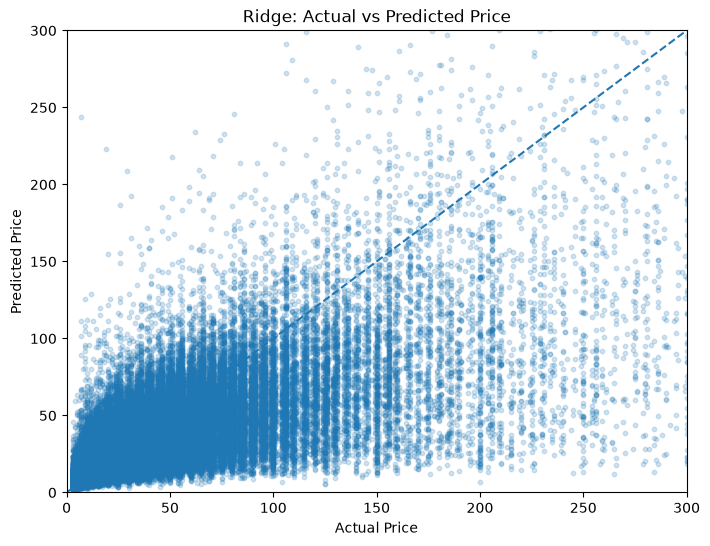

In [35]:
import matplotlib.pyplot as plt
import numpy as np

actual_price = np.expm1(y_valid)
pred_price = np.expm1(pred)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_price,
    pred_price,
    alpha=0.2,
    s=10
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Ridge: Actual vs Predicted Price')

plt.xlim(0, 300)
plt.ylim(0, 300)

plt.plot(
    [0, 300],
    [0, 300],
    linestyle='--'
)

plt.show()

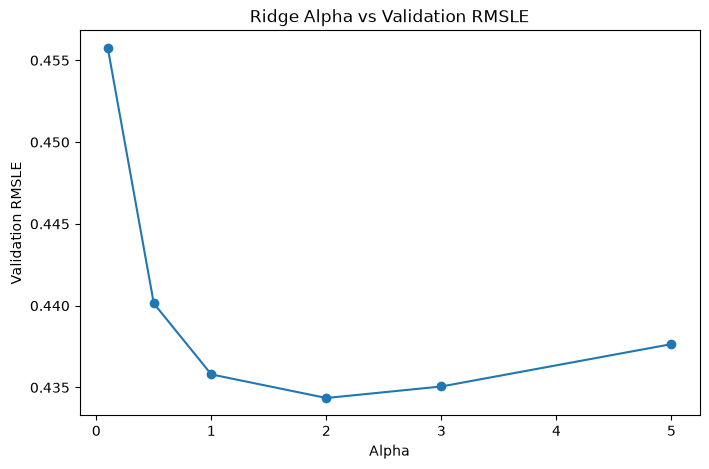

In [36]:
import matplotlib.pyplot as plt

alphas = [0.1, 0.5, 1.0, 2.0, 3.0,5.0]
rmsle_scores = [
    0.4557548155812145,
    0.4401367775632817,
    0.4357978914817806,
    0.43435494059237906,
    0.4350588333031306,
    0.4376482547577345
]

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    rmsle_scores,
    marker='o'
)

plt.xlabel('Alpha')
plt.ylabel('Validation RMSLE')
plt.title('Ridge Alpha vs Validation RMSLE')

plt.show()

In [37]:
import numpy as np
import pandas as pd

product_features = [
    'product_' + x
    for x in product_tfidf.get_feature_names_out()
]

desc_features = [
    'desc_' + x
    for x in description_tfidf.get_feature_names_out()
]

num_features = [
    'item_condition_id',
    'shipping'
]

feature_names = (
    product_features
    + desc_features
    + num_features
)

In [38]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge.coef_
})

In [39]:
coef_df.head()

,feature,coef
0,product_00,-0.206929
1,product_00 18,-0.048596
2,product_00 abercrombie,-0.018827
3,product_00 american,-0.118813
4,product_00 beauty,-0.133480


In [40]:
negative_features = (
    coef_df
    .sort_values('coef', ascending=True)
    .head(20)
)

negative_features

,feature,coef
44385,product_dust bag,-2.030233
30956,product_charger,-1.492029
127235,product_sticker,-1.453772
44393,product_dustbag,-1.244148
44384,product_dust,-1.239684
194794,desc_envelope,-1.239184
29659,product_case,-1.190250
127282,product_stickers,-1.149661
286747,desc_tracking,-1.118847
170539,desc_box only,-1.112761


In [41]:
positive_features = (
    coef_df
    .sort_values('coef', ascending=False)
    .head(20)
)

positive_features

,feature,coef
151488,desc_14k,2.515680
150692,desc_10k,1.916544
151183,desc_128gb,1.898650
289155,desc_unlocked,1.812244
114778,product_scott women,1.710136
223489,desc_limbs,1.685441
58232,product_gucci,1.669366
155551,desc_64gb,1.654223
151762,desc_16gb,1.635685
153841,desc_32gb,1.599584
